# Starburst99: Stellar Population Synthesis

This notebook demonstrates the `pyathena.util.sb99` module, which reads and
analyses output from the [Starburst99](https://www.stsci.edu/science/starburst99/)
stellar population synthesis code.

We use a solar-metallicity ($Z = 0.014$), instantaneous-burst cluster of
$10^6\,M_\odot$ with Geneva standard tracks (no rotation; Leitherer et al. 1999).

> **Dataset note:** Two bundled datasets are stored under `data/sb99/`, with
> `.spectrum1` files compressed as `.bz2` to reduce size:
>
> * `Z014_M1E6_GenevaV00_dt02/` — sub-sampled from a full Starburst99 run with
>   uniform $\Delta t = 0.1$ Myr (1000 steps, 0–100 Myr) to 251 uniform steps
>   at $\Delta t = 0.2$ Myr (0–50 Myr). Used for this notebook.
> * `Z014_M1E6_GenevaV00_logdt_10Gyr/` — sub-sampled from a log-spaced
>   Starburst99 run (378 steps, 2 Myr–10 Gyr) to 77 log-spaced steps.
>   Used together with the above for ISRF calculations
>   (`sb99.get_ISRF_SB99_plane_parallel`).
>
> All other output files (`.power1`, `.snr1`, etc.) are copied from the
> original runs without modification.

**Topics covered:**
1. Loading SB99 data
2. SED evolution
3. Band-integrated luminosities and momentum injection rates
4. Dust cross sections and mean photon energies vs age
5. Supernova and stellar wind feedback


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as au
import astropy.constants as ac

import pyathena as pa
from pyathena.util import sb99
from pyathena.plt_tools.set_plt import set_plt_fancy

set_plt_fancy()

# Path to the bundled SB99 dataset
import pathlib
REPO = pathlib.Path(pa.__file__).parent.parent
BASEDIR = REPO / 'data' / 'sb99' / 'Z014_M1E6_GenevaV00_dt02'

## 1. Load SB99 data

`SB99` discovers the output files automatically from the directory.

In [2]:
sb = sb99.SB99(str(BASEDIR), verbose=True)

rr = sb.read_rad()    # radiation output
rw = sb.read_wind()   # stellar wind power and momentum
rs = sb.read_sn()     # supernova rate and energy

[SB99-INFO] basedir: /Users/jgkim/Dropbox/Projects/pyathena/data/sb99/Z014_M1E6_GenevaV00_dt02


[SB99-INFO] Fixed mass; logM: 6.00, tmax: 100.0 Myr


[SB99-INFO] IMF: 2 interval(s), exponents=[1.3, 2.3], mass limits=[0.1, 0.5, 100.0] Msun


[SB99-INFO] Tracks: GENEVA v00 (IZ=54, Z=0.014); SN cutoff: 8 Msun; wind model: 0 (Maeder)


[SB99-INFO] Time range: 0.01 – 50.0 Myr  (251 steps)


[SB99-INFO] Wavelength range: 91 – 1600000 Å  (1221 points)


[SB99-INFO] Band luminosity keys: ['tot', 'LyC', 'LW', 'PE', 'OPT', 'IR', 'FUV', 'UV']


[SB99-INFO] Wind: time 0.01–99.9 Myr  (1000 steps); peak Edot_all 5.28e+00 Lsun Msun-1 at 3.2 Myr


[SB99-INFO] SN: time 0.01–99.9 Myr  (1000 steps); peak rate 5.93e-10 yr-1 Msun-1 at 4.7 Myr


### Return fields of `read_rad()`

`read_rad()` returns a dictionary `rr` with the following keys:

| Key | Type | Description |
|-----|------|-------------|
| `time_Myr`, `time_yr` | 1-D array (ntime,) | Stellar population age [Myr, yr] |
| `wav` | 1-D array (nwav,) | Wavelength grid [Å] |
| `logf` | 2-D array (ntime, nwav) | $\log_{10} L_\lambda$ [erg s$^{-1}$ Å$^{-1}$] for the full cluster of mass $10^{\rm logM}\,M_\odot$. Specific luminosity per $M_\odot$: `10**(logf - logM)` |
| `logM` | float | $\log_{10}$ cluster mass [$M_\odot$] |
| `df` | DataFrame | Raw per-timestep spectral table with columns `time_Myr`, `wav`, `logf`, `logfstar`, `logfneb` |
| `L` | dict of arrays | Specific luminosity [$L_\odot\,M_\odot^{-1}$]; keys: `'tot'`, `'LyC'`, `'LW'`, `'PE'`, `'FUV'`, `'OPT'`, `'IR'` |
| `pdot` | dict of arrays | Specific radiation momentum rate [$M_\odot\,\mathrm{km\,s^{-1}\,Myr^{-1}}\,M_\odot^{-1}$]; same keys as `L` |
| `Q` | dict of arrays | Specific ionizing-photon rate [s$^{-1}\,M_\odot^{-1}$]; same keys as `L` |
| `Cext`, `Cabs`, `Crpr` | dict of arrays | Luminosity-weighted mean dust cross sections per H nucleon [cm$^2$ H$^{-1}$] |
| `hnu` | dict of arrays | Luminosity-weighted mean photon energy [eV] |
| `sigma_pi_H`, `sigma_pi_H2` | array | Luminosity-weighted mean PI cross section for H and H$_2$ [cm$^2$] |
| `dhnu_H_LyC`, `dhnu_H2_LyC` | array | Mean excess photon energy above ionization threshold for H and H$_2$ [eV] |
| `tdecay_lum` | dict | Luminosity-weighted mean emission time [Myr] |
| `tcumul_lum_50/90` | dict | Age at which 50%/90% of cumulative band luminosity is emitted [Myr] |
| `*_avg`, `*_Lavg`, `*_Qavg` | dict | Time-, $L$-, and $Q$-weighted cumulative running averages |


## 2. SED evolution

The figure has two panels:

- **Top:** Dust extinction ($C_{\rm ext}/\mu_H$, solid) and absorption
  ($\kappa_{\rm abs}$, dashed) cross sections per unit gas mass as a function
  of wavelength, from the Weingartner \& Draine (2001) dust model ($R_V = 3.1$).
- **Bottom:** $L_\lambda / M_*$ as a function of wavelength at different ages,
  color-coded from blue (young) to red (old).
  Grey bands mark the LyC ($<912\,\text{Å}$), LW ($912–1108\,\text{Å}$),
  and PE ($1108–2068\,\text{Å}$) bands used for band integration.


0.0 0.6 1.2 1.8 2.4 3.0 3.6 4.2 4.8 5.4 6.0 6.6 7.2 7.8 8.4 9.0 9.6 10.2 10.8 11.4 12.0 12.6 13.2 13.8 14.4 15.0 15.6 16.2 16.8 17.4 18.0 18.6 19.2 19.8 20.4 21.0 21.6 22.2 22.8 23.4 24.0 24.6 25.2 25.8 26.4 27.0 27.6 28.2 28.8 29.4 30.0 30.6 31.2 31.8 32.4 33.0 33.6 34.2 34.8 35.4 36.0 36.6 37.2 37.8 38.4 39.0 39.6 40.2 40.8 41.4 42.0 42.6 43.2 43.8 44.4 45.0 45.6 46.2 46.8 47.4 48.0 48.6 49.2 49.8 

/Users/jgkim/Dropbox/Projects/pyathena/pyathena/util/sb99.py:753: RuntimeWarning: divide by zero encountered in divide
  return 1.0/(ac.h.cgs.value*ac.c.cgs.value/1e-8/(1.0*au.eV).cgs.value)/x


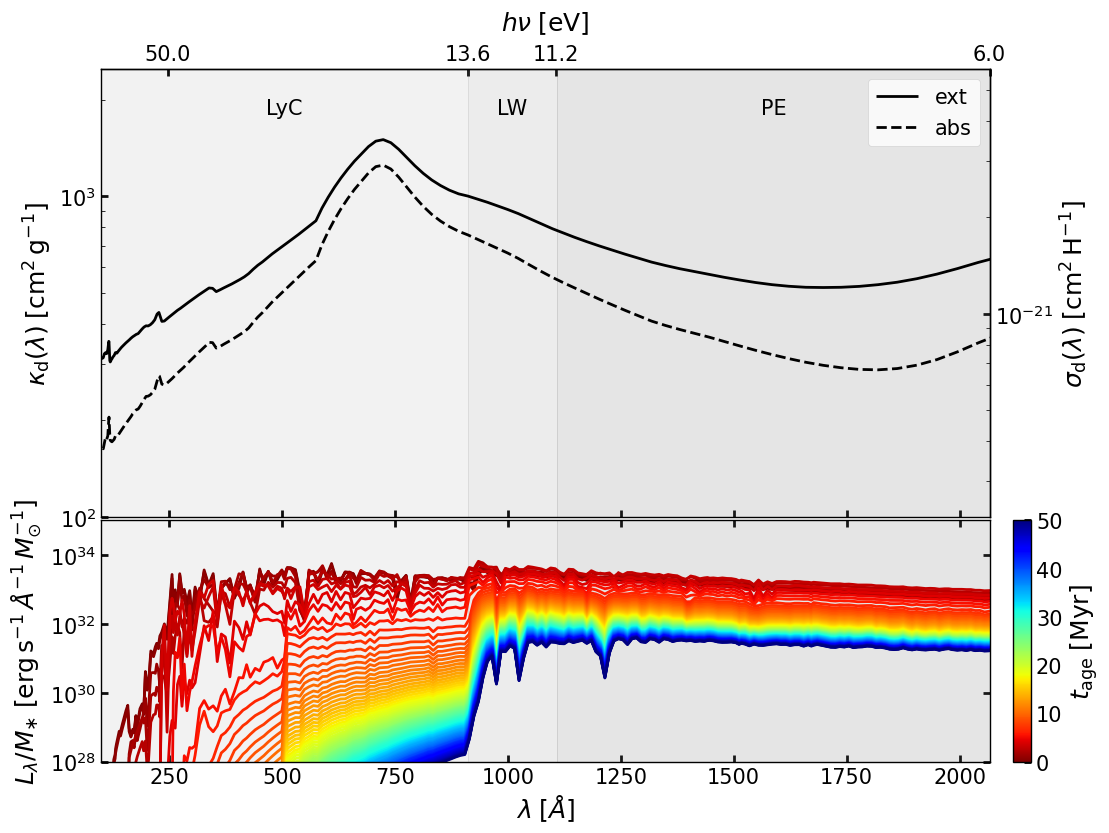

In [3]:
fig = sb.plt_spec_sigmad(rr, tmax=50.0, nstride=3, plt_isrf=False)

## 3. Band-integrated luminosity and momentum vs age

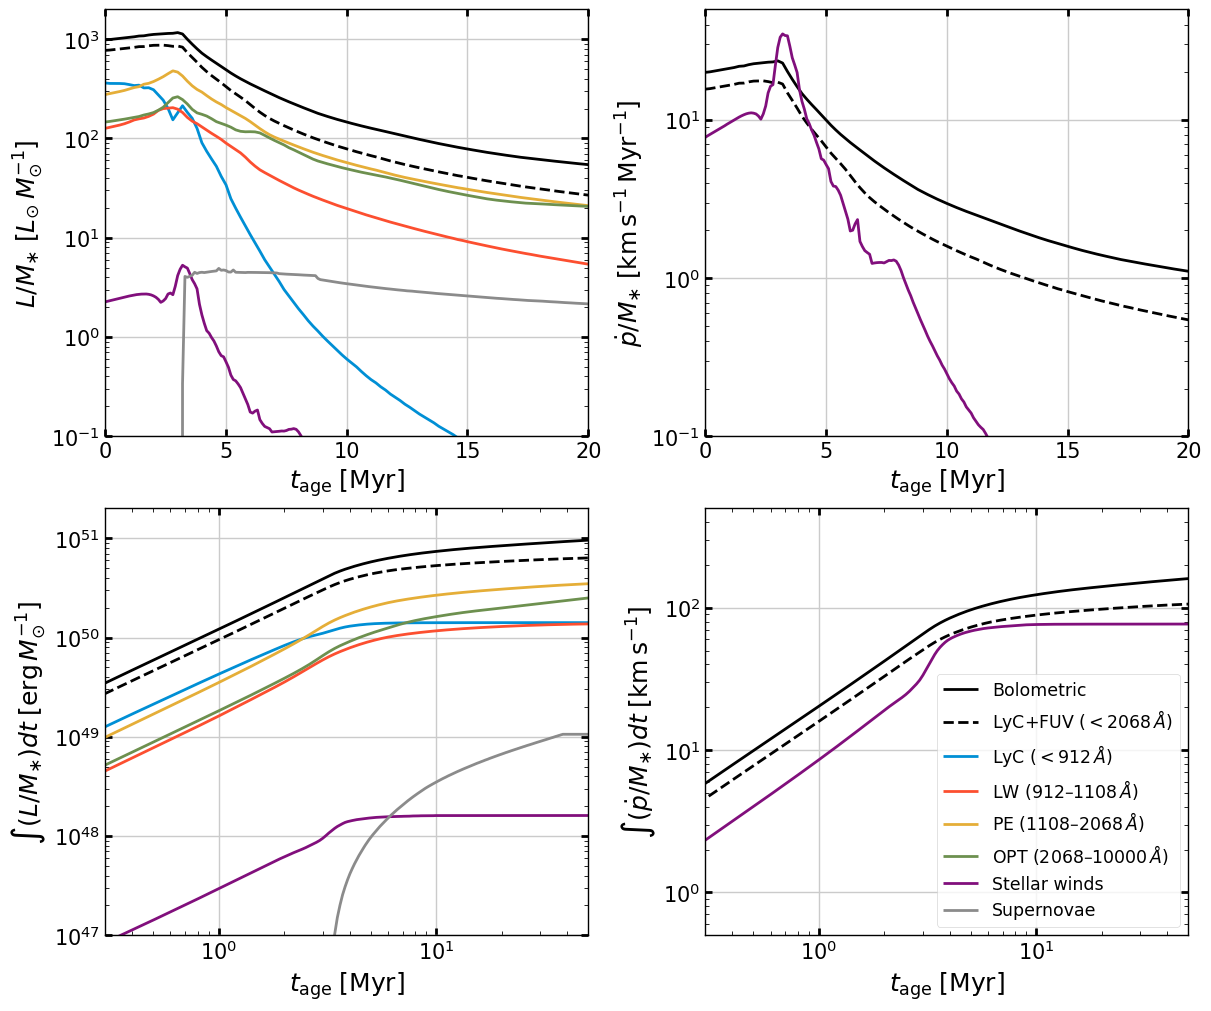

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True,
                         gridspec_kw=dict(height_ratios=[0.5, 0.5]))
axes = axes.flatten()

sb.plt_lum_evol(axes[0], rr, rw, rs, plt_sn=True)
sb.plt_pdot_evol(axes[1], rr, rw, rs)
sb.plt_lum_cumul(axes[2], rr, rw, rs, normed=False, plt_sn=True)
sb.plt_pdot_cumul(axes[3], rr, rw, rs, normed=False)

for ax in axes:
    ax.grid()

import matplotlib as mpl
plt.legend(
    [mpl.lines.Line2D([0],[0],c='k'),
     mpl.lines.Line2D([0],[0],c='k',ls='--'),
     mpl.lines.Line2D([0],[0],c='C0'),
     mpl.lines.Line2D([0],[0],c='C1'),
     mpl.lines.Line2D([0],[0],c='C2'),
     mpl.lines.Line2D([0],[0],c='C3'),
     mpl.lines.Line2D([0],[0],c='C7'),
     mpl.lines.Line2D([0],[0],c='C8')],
    ['Bolometric', r'LyC+FUV ($<2068\,\AA$)',
     r'LyC ($<912\,\AA$)', r'LW ($912$–$1108\,\AA$)',
     r'PE ($1108$–$2068\,\AA$)', r'OPT ($2068$–$10000\,\AA$)',
     'Stellar winds', 'Supernovae'],
    loc=4, fontsize='small')

plt.show()

### Luminosity-weighted timescales

The luminosity-weighted decay timescale $t_{\rm decay} = \int L\,t\,dt / \int L\,dt$
and the times by which 50% and 90% of the cumulative energy has been emitted.

In [5]:
print('{:<6s}  {:>12s}  {:>14s}  {:>14s}'.format(
    'Band', 't_decay (Myr)', 't_cumul_50 (Myr)', 't_cumul_90 (Myr)'))
print('-' * 52)
for k in ['LyC', 'LW', 'PE', 'FUV', 'OPT', 'tot']:
    print('{:<6s}  {:>12.1f}  {:>14.1f}  {:>14.1f}'.format(
        k,
        rr['tdecay_lum'][k],
        rr['tcumul_lum_50'][k],
        rr['tcumul_lum_90'][k]))

Band    t_decay (Myr)  t_cumul_50 (Myr)  t_cumul_90 (Myr)
----------------------------------------------------
LyC              1.9             1.6             3.8
LW               5.9             3.4            13.6
PE               8.1             4.0            22.6
FUV              7.5             3.8            20.0
OPT             11.5             6.0            32.8
tot              8.0             3.6            23.2


### Accessing band-integrated luminosities

The `rr['L']` dictionary stores luminosity per solar mass (erg s$^{-1}$ M$_{\odot}^{-1}$) as a function of time for each band.
Below is a minimal example.

In [6]:
Mcluster = 1e6  # Msun
t = rr['time_Myr']         # shape (N_time,)
L_LyC = rr['L']['LyC']    # L_sun/Msun, shape (N_time,)

# Luminosity at a specific age
i3 = np.argmin(np.abs(t - 3.0))
print(f'LyC luminosity at t = {t[i3]:.1f} Myr: '
      f'{L_LyC[i3]*Mcluster:.2e} Lsun  (for {Mcluster:.1e} Msun cluster)')

# Peak luminosity
ipeak = np.argmax(L_LyC)
print(f'Peak LyC luminosity:            {L_LyC[ipeak]*Mcluster:.2e} Lsun  at t = {t[ipeak]:.1f} Myr')

LyC luminosity at t = 3.0 Myr: 1.81e+08 Lsun  (for 1.0e+06 Msun cluster)
Peak LyC luminosity:            3.62e+08 Lsun  at t = 0.0 Myr


## 4. Dust cross sections and mean photon energies vs age

Luminosity-weighted mean dust extinction/absorption cross section per H atom
($\langle \sigma_d \rangle$), photoionization cross sections for H and H$_2$
($\langle \sigma_{\rm pi} \rangle$), and mean photon energies ($\langle h\nu \rangle$)
as a function of stellar age for each radiation band.

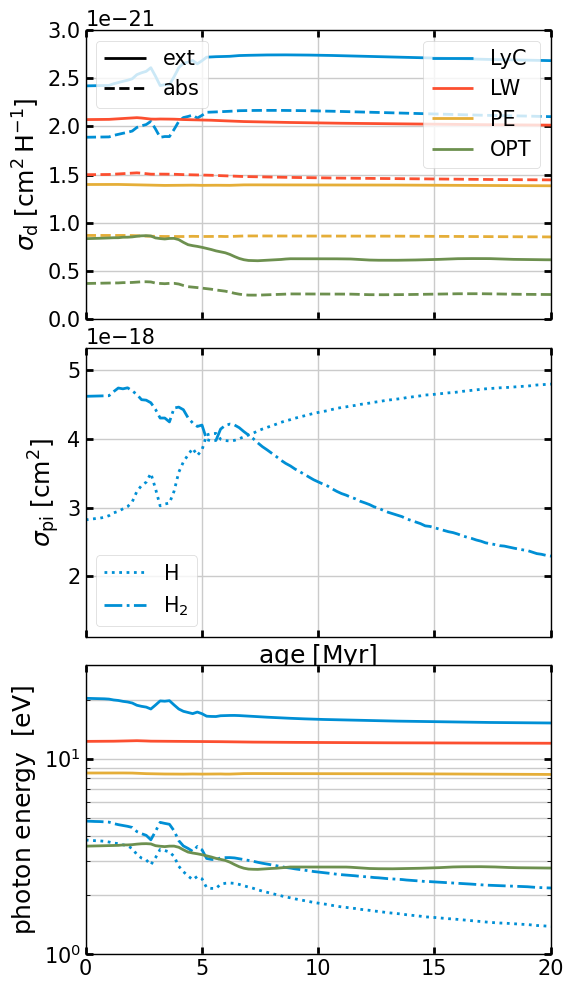

In [7]:
fig = sb99.plt_cross_sections_hnu(rr)

### Time-averaged values (first 20 Myr)

Print luminosity- and photon-rate-weighted averages of cross sections
and mean photon energies over the first 20 Myr.

In [8]:
sb99.print_lum_weighted_avg_quantities(rr, tmax=20.0)

Luminosity-weighted timescale int t*L dt/int L dt: {'tot': 8.033181841634132, 'LyC': 1.9362249576881663, 'LW': 5.872428114864254, 'PE': 8.121941423868194, 'OPT': 11.525287455130114, 'IR': 15.705568862708475, 'FUV': 7.4804580606224516, 'UV': 6.244589339918595}
Bolometric at t=0: 985.5964350981222 1165.8656320873888 3.01
Bolometric at maximum: 1165.8656320873888
Time at maximum of Bolometric: 3.01
Lyman Continuum
- 50% of LyC photons are emitted in the first 1.61 Myr
- 90% of LyC photons are emitted in the first 3.81 Myr
- 95% of LyC photons are emitted in the first 4.41 Myr
- 50% of the initial value at 2.81 Myr
FUV (LW+PE)
- 50% of FUV photons are emitted in the first 3.81 Myr
- 90% of FUV photons are emitted in the first 20.01 Myr
- 95% of FUV photons are emitted in the first 30.21 Myr
- 50% of the initial value at 6.21 Myr
LyC :
Cabs Cext Crpr hnu : 1.94e-21, 2.48e-21, 2.10e-21 1.95e+01
sigma_pi_H dhnu_H 3.08e-18, 3.46e+00
sigma_pi_H2 dhnu_H2 4.56e-18, 4.46e+00
LW :
Cabs Cext Crpr hn

## 5. Supernova and wind feedback

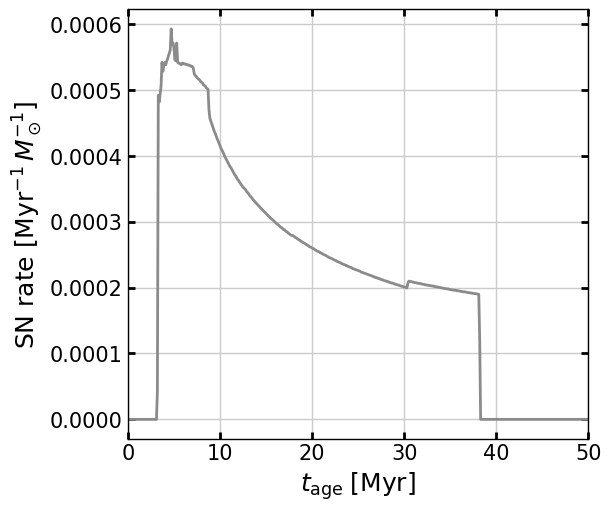

In [9]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

ax.plot(rs['time_Myr'], rs['SN_rate']*1e6, c='C8')
ax.set_xlabel(r'$t_{\rm age}\;[{\rm Myr}]$')
ax.set_ylabel(r'SN rate $[{\rm Myr}^{-1}\,M_\odot^{-1}]$')
ax.set_xlim(0, 50)
ax.grid()
plt.show()

### Stellar wind feedback

Evolution of key wind quantities per unit stellar mass as computed by Starburst99 (Leitherer et al. 1999): (a) wind luminosity, (b) wind mass-loss rate, (c) wind momentum injection rate, and (d) ratio of wind to radiation momentum injection rate.

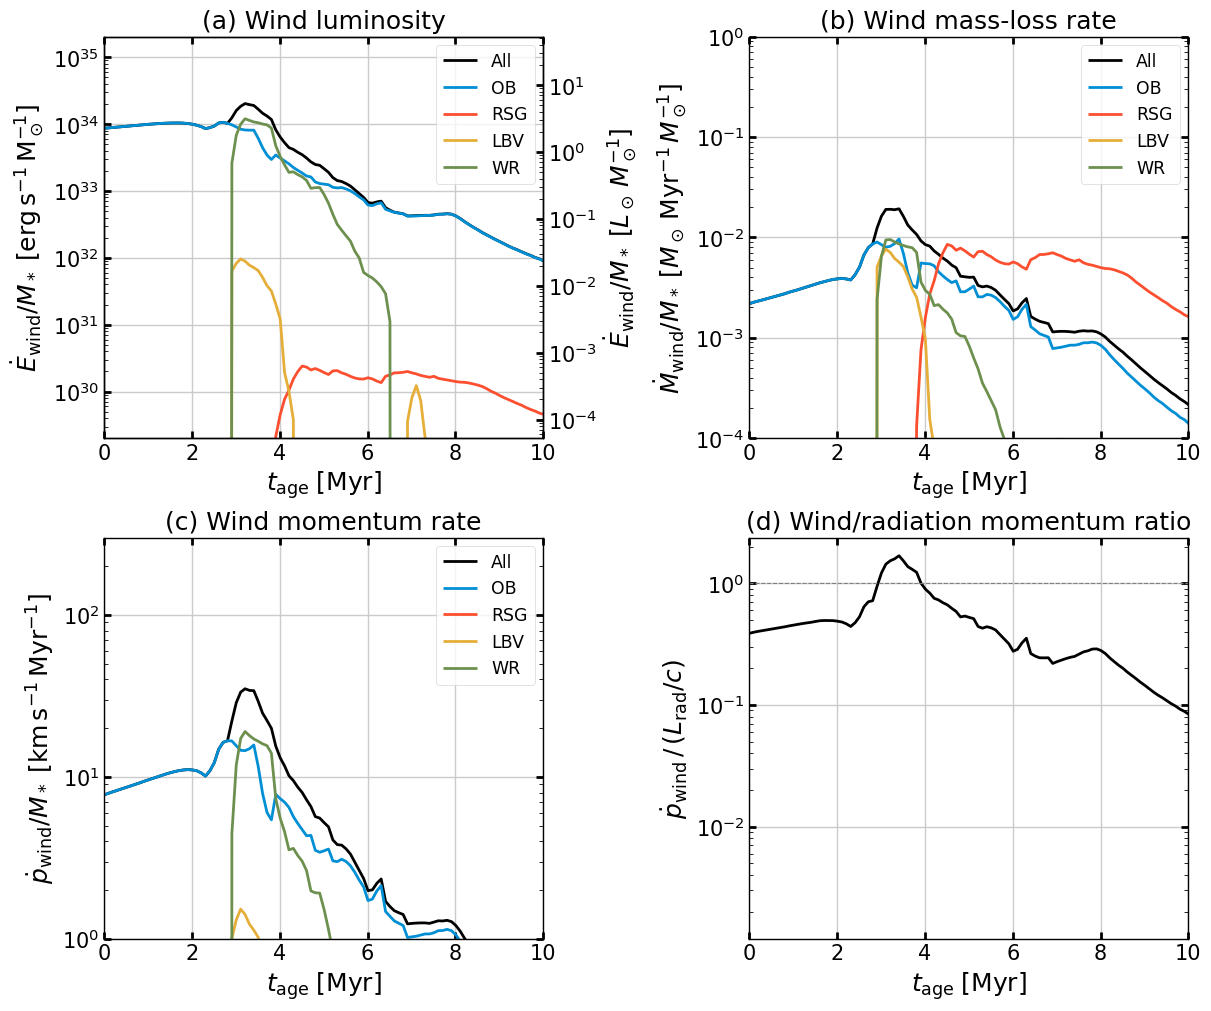

In [10]:
from scipy.interpolate import interp1d

Lsun = ac.L_sun.cgs.value
clight = ac.c.cgs.value
# pdot_wind unit in rw: Msun km/s/Myr/Msun  -->  dyne/Msun
pdot_conv = (1.0*au.Msun*au.km/au.s/au.Myr).to('dyne').value

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten()

components = [('all','k','All'), ('OB','C0','OB'),
              ('RSG','C1','RSG'), ('LBV','C2','LBV'), ('WR','C3','WR')]

# (a) Wind luminosity [erg/s/Msun], right axis [Lsun/Msun]
ax = axes[0]
for v, c, label in components:
    ax.semilogy(rw['time_Myr'], rw[f'Edot_{v}'], c=c, label=label)
ymax = rw['Edot_all'].max()
ax.set_ylim(ymax*1e-5, ymax*10)
ax2 = ax.twinx()
ax2.set_yscale('log')
ax2.set_ylim(ax.get_ylim()[0]/Lsun, ax.get_ylim()[1]/Lsun)
ax2.set_ylabel(r'$\dot{E}_{\rm wind}/M_*\;[L_\odot\,M_\odot^{-1}]$')
ax.set_ylabel(r'$\dot{E}_{\rm wind}/M_*\;[{\rm erg\,s^{-1}\,M_\odot^{-1}}]$')
ax.legend(fontsize='small')
ax.set_title('(a) Wind luminosity')

# (b) Mass-loss rate [Msun/Myr/Msun]
ax = axes[1]
for v, c, label in components:
    ax.semilogy(rw['time_Myr'], rw[f'Mdot_{v}'], c=c, label=label)
ax.set_ylim(1e-4, 1e0)
ax.set_ylabel(r'$\dot{M}_{\rm wind}/M_*\;[M_\odot\,{\rm Myr}^{-1}\,M_\odot^{-1}]$')
ax.legend(fontsize='small')
ax.set_title('(b) Wind mass-loss rate')

# (c) Wind momentum rate [km/s/Myr]
#     pdot_all in rw is Msun km/s/Myr / Msun = km/s/Myr
ax = axes[2]
for v, c, label in components:
    ax.semilogy(rw['time_Myr'], rw[f'pdot_{v}'], c=c, label=label)
ax.set_ylim(1e0, 3e2)
ax.set_ylabel(r'$\dot{p}_{\rm wind}/M_*\;[{\rm km\,s^{-1}\,Myr^{-1}}]$')
ax.legend(fontsize='small')
ax.set_title('(c) Wind momentum rate')

# (d) Ratio pdot_wind / (L_rad/c)
#     rr['L']['tot'] is in Lsun/Msun; convert to erg/s/Msun before dividing by c
ax = axes[3]
L_tot_interp = interp1d(rr['time_Myr'], rr['L']['tot'],
                        bounds_error=False, fill_value='extrapolate')
L_rad_cgs = L_tot_interp(rw['time_Myr']) * Lsun  # erg/s/Msun
pdot_rad = L_rad_cgs / clight                      # dyne/Msun
pdot_wind_cgs = rw['pdot_all'] * pdot_conv
ratio = pdot_wind_cgs / pdot_rad
ax.semilogy(rw['time_Myr'], ratio, c='k')
ax.axhline(1, ls='--', c='gray', lw=0.8)
ax.set_ylabel(r'$\dot{p}_{\rm wind}\,/\,(L_{\rm rad}/c)$')
ax.set_title('(d) Wind/radiation momentum ratio')

for ax in axes:
    ax.set_xlabel(r'$t_{\rm age}\;[{\rm Myr}]$')
    ax.set_xlim(0, 10)
    ax.grid()

plt.show()

## 6. Interstellar Radiation Field (ISRF)

The function `sb99.get_ISRF_SB99_plane_parallel` estimates the angle-averaged
mean intensity $J_\lambda$ at the midplane of a plane-parallel disk under a
constant star-formation history, following Ostriker et al. (2010):

$$J_\lambda = \frac{L_\lambda / {\rm SFR}}{4\pi} \cdot \Sigma_{\rm SFR}
              \cdot \frac{1 - E_2(\tau_\perp/2)}{\tau_\perp}$$

where $\tau_\perp(\lambda)$ is the wavelength-dependent perpendicular dust
optical depth and $E_2$ is the second exponential integral.

By default the function stitches the fine-resolution short-timescale dataset
(dt = 0.2 Myr, 0–50 Myr) with the log-spaced long-timescale dataset
(2 Myr–10 Gyr) and integrates over a constant SFH up to $t_{\rm max} = 10$ Gyr:

$$\frac{L_\lambda}{\rm SFR} = \int_0^{t_{\rm max}}
  \frac{L_\lambda^{\rm SSP}(t)}{M_*}\,dt$$


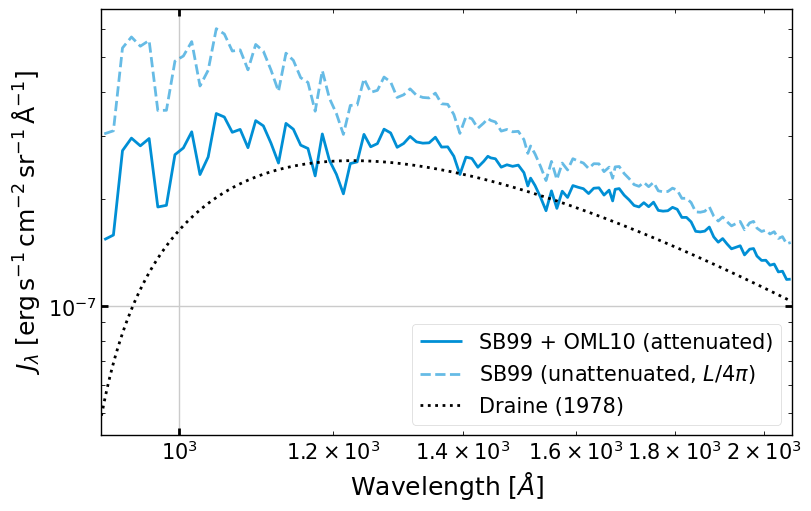


Band-integrated FUV mean intensity:
  J_FUV (attenuated) : 2.596e-04 erg / (s sr cm2)
  J_FUV (unattenuated): 3.604e-04 erg / (s sr cm2)
  Attenuation factor  : 0.720


In [11]:
from pyathena.util import sb99
from pyathena.util.rad_isrf import nuJnu_Dr78

# Compute midplane ISRF for typical ISM conditions
r = sb99.get_ISRF_SB99_plane_parallel(
    Sigma_gas=10.0*au.M_sun/au.pc**2,
    Sigma_SFR=2.5e-3*au.M_sun/au.kpc**2/au.yr,
    verbose=False)

w = r['w_angstrom']
idx_fuv = (w > 912) & (w < 2068)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# Attenuated and unattenuated midplane ISRF
l, = ax.loglog(w[idx_fuv], r['Jlambda'][idx_fuv],
               label=r'SB99 + OML10 (attenuated)')
ax.loglog(w[idx_fuv], r['Jlambda_unatt'][idx_fuv],
          c=l.get_color(), ls='--', alpha=0.6,
          label=r'SB99 (unattenuated, $L/4\pi$)')

# Draine (1978) reference ISRF
wav_dr = np.logspace(np.log10(912), np.log10(2068), 500)*au.angstrom
nu_dr  = (ac.c / wav_dr).to('Hz')
E_dr   = (nu_dr * ac.h).to('eV')
J_dr78 = nuJnu_Dr78(E_dr) / wav_dr   # nuJnu / lambda = J_lambda
ax.loglog(wav_dr.value, J_dr78.to('erg s-1 cm-2 angstrom-1 sr-1').value,
          c='k', ls=':', label='Draine (1978)')

ax.set_xlabel(r'Wavelength $[\AA]$')
ax.set_ylabel(r'$J_\lambda\;[{\rm erg\,s^{-1}\,cm^{-2}\,sr^{-1}\,\AA^{-1}}]$')
ax.set_xlim(912, 2068)
ax.legend()
ax.grid()
plt.show()

print(f"\nBand-integrated FUV mean intensity:")
print(f"  J_FUV (attenuated) : {r['J_FUV']:.3e}")
print(f"  J_FUV (unattenuated): {r['J_FUV_unatt']:.3e}")
print(f"  Attenuation factor  : {(r['J_FUV']/r['J_FUV_unatt']).decompose().value:.3f}")